In [27]:
import pandas as pd

df = pd.read_csv("data/syn_lathe_jsdata.csv")

print(df.shape)
df.head()

(5000, 12)


,availability,performance,quality,speed,downtime_minutes,shutdown_minutes,machine_issue,trend,current_oee,future_oee,income,loss
0,97.97,74.25,82.65,17,3,0,0,1,60.12,64.85,3891,2109
1,92.57,85.33,97.30,10,7,4,0,1,76.86,82.35,4940,1060
2,81.96,67.37,80.41,17,17,2,0,-1,44.40,39.48,2368,3632
3,97.24,32.38,100.00,7,0,2,0,-1,31.48,28.38,1702,4298
4,80.18,93.02,91.27,15,19,0,0,0,68.08,68.45,4107,1893


In [121]:
PROCESS_FEATURES = [
    "speed",
    "downtime_minutes",
    "shutdown_minutes",
    "machine_issue",
    "trend"
]

X_process = df[PROCESS_FEATURES]

y_performance = df["performance"]
y_quality = df["quality"]
y_availability = df["availability"]

print(X_process.shape)

X_process.head()

(5000, 5)


,speed,downtime_minutes,shutdown_minutes,machine_issue,trend
0,17,3,0,0,1
1,10,7,4,0,1
2,17,17,2,0,-1
3,7,0,2,0,-1
4,15,19,0,0,0


In [125]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X_process,
    y_performance,
    test_size=0.2,
    random_state=42
)

performance_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("regressor", LinearRegression())
])

performance_model.fit(X_train, y_train)

preds = performance_model.predict(X_test)

print("Performance Model")
print("R² :", round(r2_score(y_test, preds), 4))
print("MAE:", round(mean_absolute_error(y_test, preds), 4))

Performance Model
R² : 0.9901
MAE: 1.5256


In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X_process,
    y_quality,
    test_size=0.2,
    random_state=42
)

quality_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("regressor", LinearRegression())
])

quality_model.fit(X_train, y_train)

preds = quality_model.predict(X_test)

print("Quality Model")
print("R² :", round(r2_score(y_test, preds), 4))
print("MAE:", round(mean_absolute_error(y_test, preds), 4))

Quality Model
R² : 0.9242
MAE: 1.6107


In [127]:
X_train, X_test, y_train, y_test = train_test_split(
    X_process,
    y_availability,
    test_size=0.2,
    random_state=42
)

availability_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("regressor", LinearRegression())
])

availability_model.fit(X_train, y_train)

preds = availability_model.predict(X_test)

print("Availability Model")
print("R² :", round(r2_score(y_test, preds), 4))
print("MAE:", round(mean_absolute_error(y_test, preds), 4))

Availability Model
R² : 0.966
MAE: 1.268


In [128]:
FEATURES = [
    "availability",
    "performance",
    "quality",
    "speed",
    "downtime_minutes",
    "shutdown_minutes",
    "machine_issue",
    "trend"
]

TARGET = "future_oee"

X = df[FEATURES]
y = df[TARGET]

In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4000, 8)
(1000, 8)


In [130]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [131]:
models = {
    "MultipleLinearRegression": LinearRegression(),

    "PolynomialRegression_Degree2": Pipeline([
        (
            "poly",
            PolynomialFeatures(
                degree=2,
                include_bias=False
            )
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]),

    "PolynomialRegression_Degree3": Pipeline([
        (
            "poly",
            PolynomialFeatures(
                degree=3,
                include_bias=False
            )
        ),
        (
            "regressor",
            LinearRegression()
        )
    ])
}

In [132]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    preds = model.predict(
        X_test
    )

    results.append({
        "Model": name,
        "R2": round(
            r2_score(
                y_test,
                preds
            ),
            4
        ),
        "MAE": round(
            mean_absolute_error(
                y_test,
                preds
            ),
            4
        ),
        "RMSE": round(
            mean_squared_error(
                y_test,
                preds
            ) ** 0.5,
            4
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "R2",
    ascending=False
)

,Model,R2,MAE,RMSE
1,PolynomialRegression_Degree2,0.9950,1.0281,1.2895
2,PolynomialRegression_Degree3,0.9948,1.0479,1.3156
0,MultipleLinearRegression,0.9832,1.8708,2.3623


In [133]:
best_model = models["PolynomialRegression_Degree2"]

best_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [134]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    explained_variance_score,
)

preds = best_model.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = mse ** 0.5
mape = mean_absolute_percentage_error(y_test, preds)
evs = explained_variance_score(y_test, preds)

sse = ((y_test - preds) ** 2).sum()

print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4%}")
print(f"EVS:  {evs:.4f}")
print(f"SSE:  {sse:.4f}")

R²:   0.9950
MAE:  1.0281
MSE:  1.6629
RMSE: 1.2895
MAPE: 2.0635%
EVS:  0.9950
SSE:  1662.9121


In [135]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": result.importances_mean
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
1,performance,1.345074
0,availability,0.271491
2,quality,0.119946
7,trend,0.047116
4,downtime_minutes,0.003310
5,shutdown_minutes,0.003249
3,speed,0.002523
6,machine_issue,0.000705


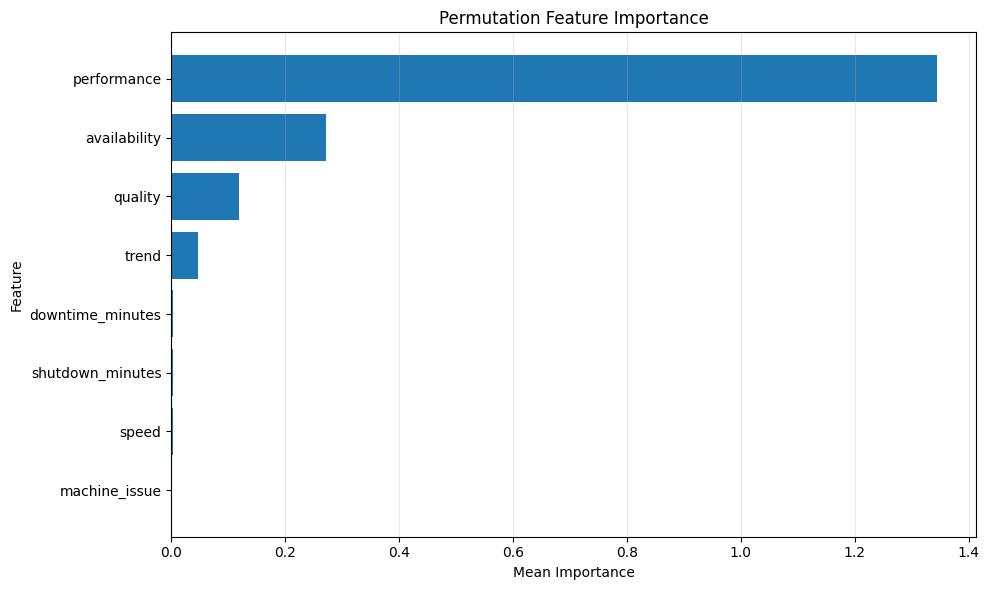

In [136]:
import matplotlib.pyplot as plt

importance = importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Permutation Feature Importance"
)

plt.xlabel(
    "Mean Importance"
)

plt.ylabel(
    "Feature"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

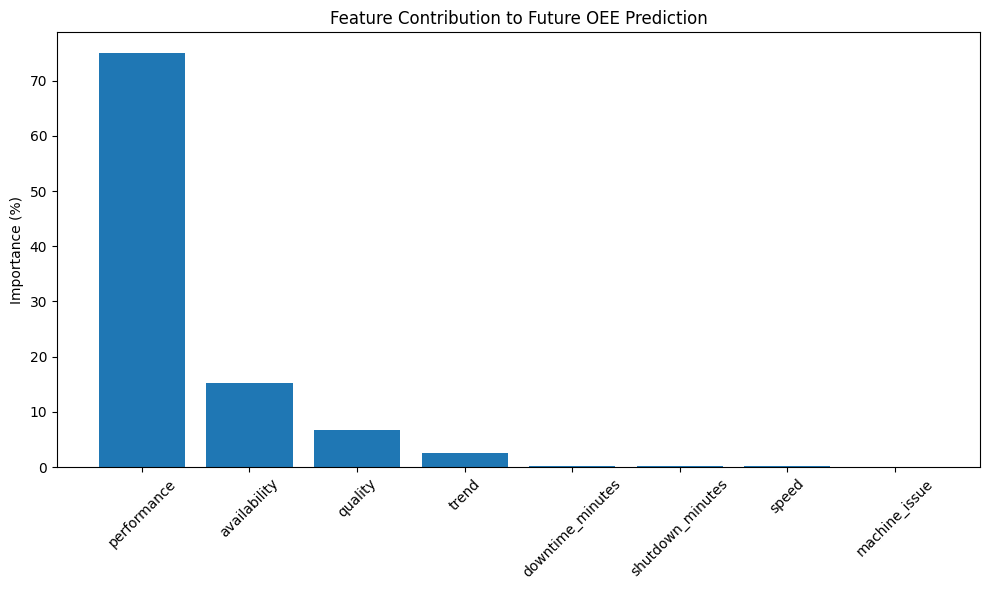

In [137]:
importance_pct = importance.copy()

importance_pct["Importance"] = (
    importance_pct["Importance"]
    / importance_pct["Importance"].sum()
) * 100

importance_pct = importance_pct.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    importance_pct["Feature"],
    importance_pct["Importance"]
)

plt.xticks(rotation=45)

plt.ylabel("Importance (%)")

plt.title(
    "Feature Contribution to Future OEE Prediction"
)

plt.tight_layout()

plt.show()

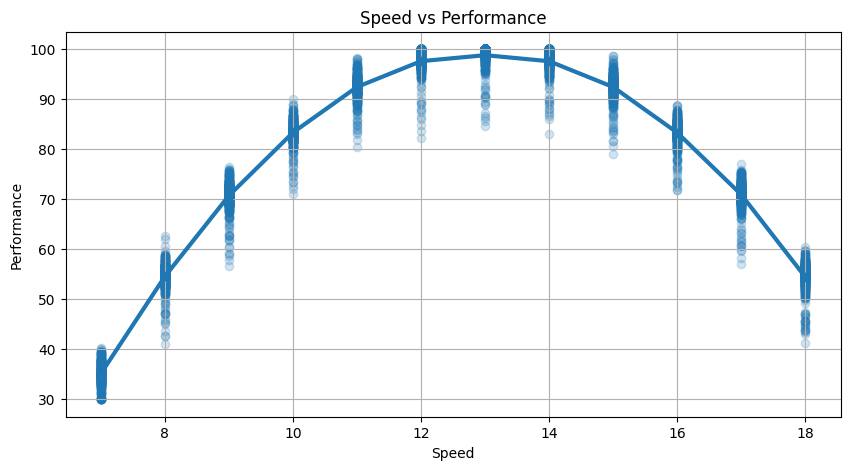

In [138]:
plt.figure(figsize=(10,5))

plt.scatter(
    df["speed"],
    df["performance"],
    alpha=0.2
)

speed_perf = (
    df
    .groupby("speed")["performance"]
    .mean()
)

plt.plot(
    speed_perf.index,
    speed_perf.values,
    marker="o",
    linewidth=3
)

plt.title(
    "Speed vs Performance"
)

plt.xlabel("Speed")
plt.ylabel("Performance")

plt.grid(True)

plt.show()

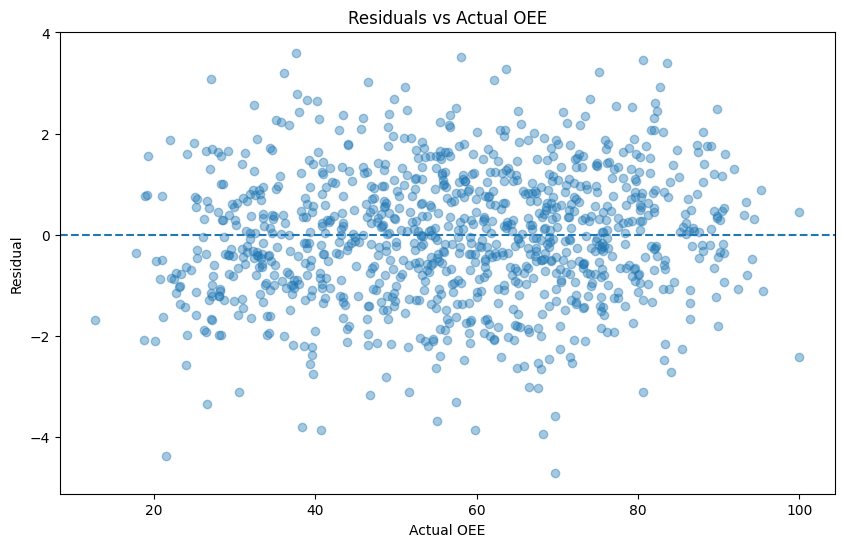

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_test - preds,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Actual OEE")
plt.ylabel("Residual")

plt.title(
    "Residuals vs Actual OEE"
)

plt.show()

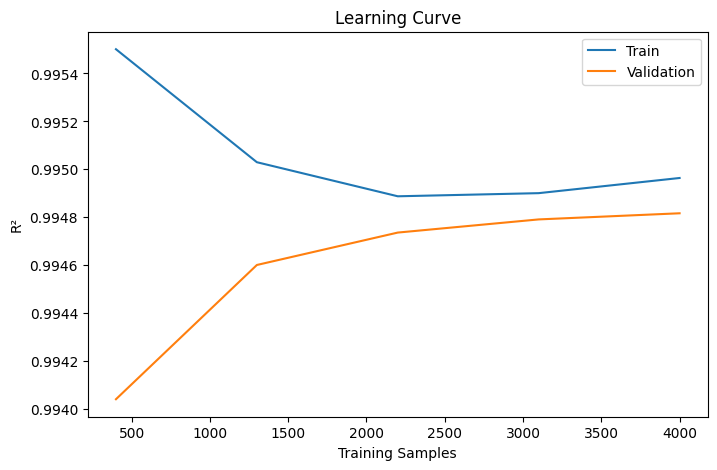

In [140]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    label="Train"
)

plt.plot(
    train_sizes,
    test_scores.mean(axis=1),
    label="Validation"
)

plt.xlabel("Training Samples")
plt.ylabel("R²")

plt.title("Learning Curve")

plt.legend()

plt.show()

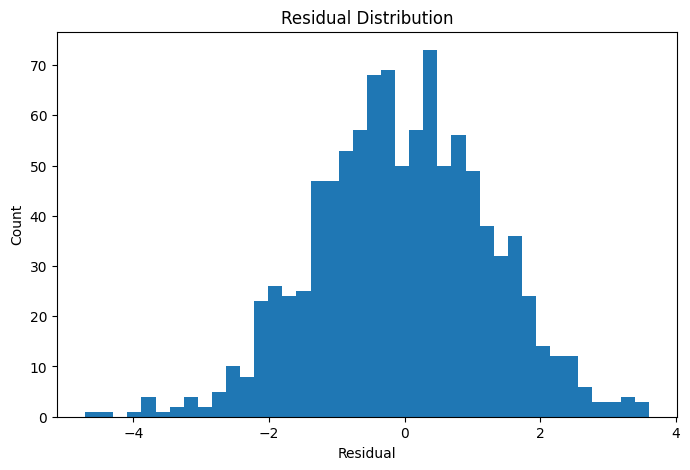

In [141]:
residuals = y_test - preds

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=40
)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")

plt.show()

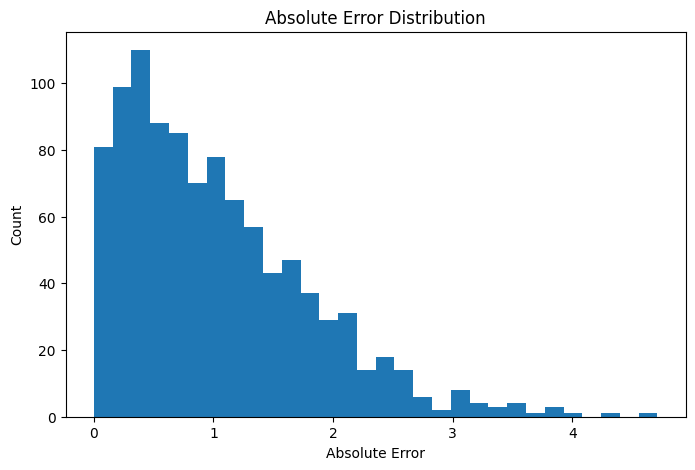

In [142]:
errors = abs(y_test - preds)

plt.figure(figsize=(8,5))

plt.hist(
    errors,
    bins=30
)

plt.xlabel("Absolute Error")
plt.ylabel("Count")
plt.title("Absolute Error Distribution")

plt.show()

In [143]:
evaluation_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": preds,
})

evaluation_df["Error"] = (
    evaluation_df["Actual"]
    - evaluation_df["Predicted"]
)

evaluation_df["Absolute_Error"] = (
    evaluation_df["Error"].abs()
)

evaluation_df.sort_values(
    "Absolute_Error",
    ascending=False
).head(20)

,Actual,Predicted,Error,Absolute_Error
3400,69.67,74.381740,-4.711740,4.711740
1034,21.58,25.965307,-4.385307,4.385307
367,68.26,72.199420,-3.939420,3.939420
3617,59.75,63.623930,-3.873930,3.873930
1946,40.72,44.587638,-3.867638,3.867638
1135,38.34,42.156477,-3.816477,3.816477
3646,55.05,58.742325,-3.692325,3.692325
4005,37.61,34.011678,3.598322,3.598322
3559,69.66,73.251936,-3.591936,3.591936
2059,58.10,54.577885,3.522115,3.522115


In [151]:
import joblib

joblib.dump(performance_model, "models/performance_model.pkl")
joblib.dump(quality_model, "models/quality_model.pkl")
joblib.dump(availability_model, "models/availability_model.pkl")
joblib.dump(best_model, "models/future_oee_model.pkl")

print("Models saved.")

Models saved.


In [145]:
excellent = pd.DataFrame([{
    "availability": 98,
    "performance": 99,
    "quality": 98,
    "speed": 13,
    "downtime_minutes": 1,
    "shutdown_minutes": 0,
    "machine_issue": 0,
    "trend": 1
}])

print(best_model.predict(excellent)[0])

99.13254788919684


In [146]:
normal = pd.DataFrame([{
    "availability": 90,
    "performance": 85,
    "quality": 95,
    "speed": 12,
    "downtime_minutes": 5,
    "shutdown_minutes": 3,
    "machine_issue": 0,
    "trend": 0
}])

print(best_model.predict(normal)[0])

72.68302643282718


In [147]:
faulty = pd.DataFrame([{
    "availability": 70,
    "performance": 60,
    "quality": 75,
    "speed": 17,
    "downtime_minutes": 15,
    "shutdown_minutes": 10,
    "machine_issue": 1,
    "trend": -1
}])

print(best_model.predict(faulty)[0])

27.781198453290386


In [148]:
sample = {
    "speed": 10,
    "downtime_minutes": 4,
    "shutdown_minutes": 2,
    "machine_issue": 0,
    "trend": 0
}

results = []

for speed in range(7, 19):

    process_input = pd.DataFrame([{
        "speed": speed,
        "downtime_minutes": sample["downtime_minutes"],
        "shutdown_minutes": sample["shutdown_minutes"],
        "machine_issue": sample["machine_issue"],
        "trend": sample["trend"]
    }])

    pred_performance = float(
        performance_model.predict(process_input)[0]
    )

    pred_quality = float(
        quality_model.predict(process_input)[0]
    )

    pred_availability = float(
        availability_model.predict(process_input)[0]
    )

    oee_input = pd.DataFrame([{
        "availability": pred_availability,
        "performance": pred_performance,
        "quality": pred_quality,
        "speed": speed,
        "downtime_minutes": sample["downtime_minutes"],
        "shutdown_minutes": sample["shutdown_minutes"],
        "machine_issue": sample["machine_issue"],
        "trend": sample["trend"]
    }])

    pred_oee = float(
        best_model.predict(oee_input)[0]
    )

    results.append({
        "speed": speed,
        "availability": round(pred_availability, 2),
        "performance": round(pred_performance, 2),
        "quality": round(pred_quality, 2),
        "future_oee": round(pred_oee, 2)
    })

opt_df = pd.DataFrame(results)

display(opt_df)

best_row = opt_df.loc[
    opt_df["future_oee"].idxmax()
]

print("\nBEST SPEED")
print(best_row)

,speed,availability,performance,quality,future_oee
0,7,94.58,35.65,95.97,32.30
1,8,94.58,55.28,97.96,51.23
2,9,94.59,71.33,99.24,66.93
3,10,94.60,83.81,99.80,79.04
4,11,94.61,92.72,99.66,87.29
5,12,94.62,98.05,98.80,91.55
6,13,94.64,99.81,97.23,91.80
7,14,94.65,98.00,94.95,88.14
8,15,94.67,92.61,91.95,80.81
9,16,94.69,83.64,88.24,70.13



BEST SPEED
speed           13.00
availability    94.64
performance     99.81
quality         97.23
future_oee      91.80
Name: 6, dtype: float64


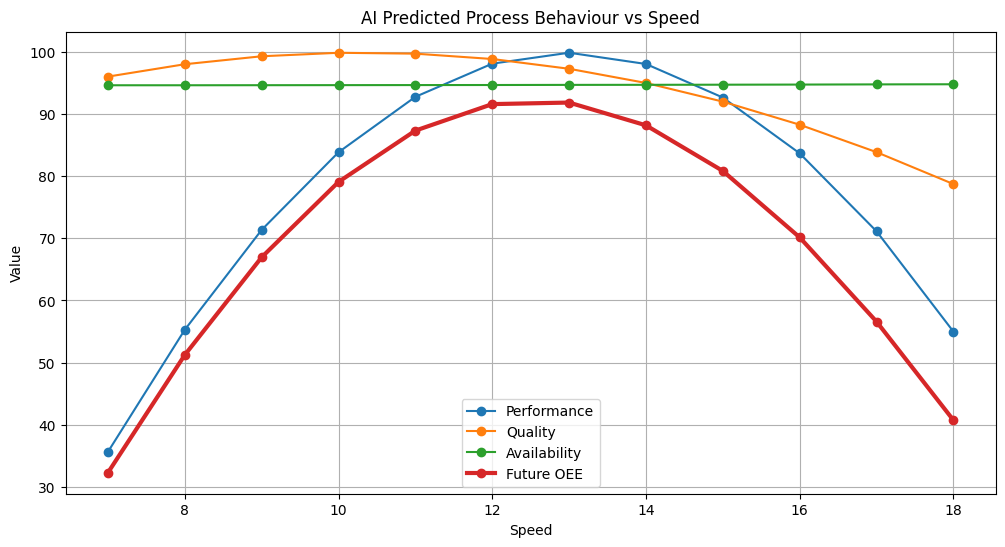

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(opt_df["speed"], opt_df["performance"], marker="o", label="Performance")
plt.plot(opt_df["speed"], opt_df["quality"], marker="o", label="Quality")
plt.plot(opt_df["speed"], opt_df["availability"], marker="o", label="Availability")
plt.plot(opt_df["speed"], opt_df["future_oee"], marker="o", linewidth=3, label="Future OEE")

plt.xlabel("Speed")
plt.ylabel("Value")
plt.title("AI Predicted Process Behaviour vs Speed")

plt.grid(True)
plt.legend()

plt.show()

,downtime,availability,performance,quality,future_oee
0,0,98.64,99.85,97.25,95.74
1,5,93.63,99.81,97.22,90.81
2,10,88.58,99.78,97.20,85.84
3,15,83.48,99.78,97.18,80.85
4,20,78.34,99.80,97.17,75.82


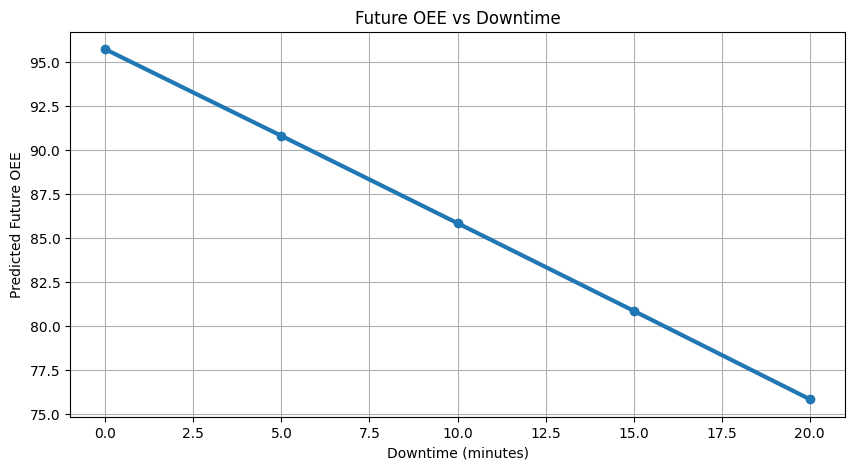

In [150]:
import pandas as pd
import matplotlib.pyplot as plt

results = []

for downtime in [0, 5, 10, 15, 20]:

    process_input = pd.DataFrame([{
        "speed": 13,
        "downtime_minutes": downtime,
        "shutdown_minutes": 2,
        "machine_issue": 0,
        "trend": 0
    }])

    pred_performance = float(
        performance_model.predict(process_input)[0]
    )

    pred_quality = float(
        quality_model.predict(process_input)[0]
    )

    pred_availability = float(
        availability_model.predict(process_input)[0]
    )

    oee_input = pd.DataFrame([{
        "availability": pred_availability,
        "performance": pred_performance,
        "quality": pred_quality,
        "speed": 13,
        "downtime_minutes": downtime,
        "shutdown_minutes": 2,
        "machine_issue": 0,
        "trend": 0
    }])

    pred_oee = float(
        best_model.predict(oee_input)[0]
    )

    results.append({
        "downtime": downtime,
        "availability": round(pred_availability, 2),
        "performance": round(pred_performance, 2),
        "quality": round(pred_quality, 2),
        "future_oee": round(pred_oee, 2)
    })

downtime_df = pd.DataFrame(results)

display(downtime_df)

plt.figure(figsize=(10,5))

plt.plot(
    downtime_df["downtime"],
    downtime_df["future_oee"],
    marker="o",
    linewidth=3
)

plt.title(
    "Future OEE vs Downtime"
)

plt.xlabel("Downtime (minutes)")
plt.ylabel("Predicted Future OEE")

plt.grid(True)

plt.show()